In [55]:
import pandas as pd

#Preview daily data from 2019
d_19 = pd.read_parquet(r"C:\Users\Shih-An\Documents\685\Capstone\run_ww_2019_d.parquet")
print(d_19.head())

    datetime  athlete  distance  duration gender age_group         country  \
0 2019-01-01        0      0.00      0.00      F   18 - 34   United States   
1 2019-01-01        1      5.27     30.20      M   35 - 54         Germany   
2 2019-01-01        2      0.00      0.00      M   35 - 54  United Kingdom   
3 2019-01-01        3     10.50     43.95      M   18 - 34  United Kingdom   
4 2019-01-01        4      9.66     48.65      M   35 - 54   United States   

                     major  
0             CHICAGO 2019  
1              BERLIN 2016  
2  LONDON 2018,LONDON 2019  
3              LONDON 2017  
4              BOSTON 2017  


In [57]:
#Preview daily data from 2020
d_20 = pd.read_parquet(r"C:\Users\Shih-An\Documents\685\Capstone\run_ww_2020_d.parquet")
print(d_20.head())

    datetime  athlete  distance   duration gender age_group         country  \
0 2020-01-01        0      0.00   0.000000      F   18 - 34   United States   
1 2020-01-01        1      5.72  31.633333      M   35 - 54         Germany   
2 2020-01-01        2      0.00   0.000000      M   35 - 54  United Kingdom   
3 2020-01-01        3      0.00   0.000000      M   18 - 34  United Kingdom   
4 2020-01-01        4      8.07  38.616667      M   35 - 54   United States   

                     major  
0             CHICAGO 2019  
1              BERLIN 2016  
2  LONDON 2018,LONDON 2019  
3              LONDON 2017  
4              BOSTON 2017  


In [58]:
#Combine daily data from 2019 and 2020

df = pd.concat([d_19, d_20], ignore_index=True)

Ensure datetime is correct type
df["datetime"] = pd.to_datetime(df["datetime"])

# Check result
print(df.head())
print(df.shape)

    datetime  athlete  distance  duration gender age_group         country  \
0 2019-01-01        0      0.00      0.00      F   18 - 34   United States   
1 2019-01-01        1      5.27     30.20      M   35 - 54         Germany   
2 2019-01-01        2      0.00      0.00      M   35 - 54  United Kingdom   
3 2019-01-01        3     10.50     43.95      M   18 - 34  United Kingdom   
4 2019-01-01        4      9.66     48.65      M   35 - 54   United States   

                     major  
0             CHICAGO 2019  
1              BERLIN 2016  
2  LONDON 2018,LONDON 2019  
3              LONDON 2017  
4              BOSTON 2017  
(26617172, 8)


In [60]:
df = df.sort_values(["datetime", "athlete"]).reset_index(drop=True)

df.to_parquet(r"C:\Users\Shih-An\Documents\685\Capstone\run_ww_2019_2020_d.parquet", index=False)



KeyboardInterrupt



In [3]:
df = pd.read_parquet(r"C:\Users\Shih-An\Documents\685\Capstone\run_ww_2019_2020_d.parquet")


In [6]:
print(df.head())
print(df.shape)
print(df.dtypes)
print(df["datetime"].min(), df["datetime"].max())

    datetime  athlete  distance  duration gender age_group         country  \
0 2019-01-01        0      0.00      0.00      F   18 - 34   United States   
1 2019-01-01        1      5.27     30.20      M   35 - 54         Germany   
2 2019-01-01        2      0.00      0.00      M   35 - 54  United Kingdom   
3 2019-01-01        3     10.50     43.95      M   18 - 34  United Kingdom   
4 2019-01-01        4      9.66     48.65      M   35 - 54   United States   

                     major  
0             CHICAGO 2019  
1              BERLIN 2016  
2  LONDON 2018,LONDON 2019  
3              LONDON 2017  
4              BOSTON 2017  
(26617172, 8)
datetime     datetime64[ns]
athlete               int64
distance            float64
duration            float64
gender               object
age_group            object
country              object
major                object
dtype: object
2019-01-01 00:00:00 2020-12-31 00:00:00


In [7]:
#Step 1: make one daily record per athlete
import pandas as pd
import numpy as np

df["date"] = df["datetime"].dt.normalize()

# convert km → miles
df["distance"] = df["distance"] * 0.621371

# pace in minutes per mile
df["pace"] = np.where(df["distance"] > 0, df["duration"] / df["distance"], np.nan)

# one row per athlete per day
daily = (
    df.groupby(["athlete", "date"], as_index=False)
      .agg(
          distance=("distance", "sum"),
          duration=("duration", "sum"),
          gender=("gender", "first"),
          age_group=("age_group", "first"),
          country=("country", "first"),
          major=("major", "first"),
      )
)

# recompute pace after aggregation
daily["pace"] = np.where(daily["distance"] > 0, daily["duration"] / daily["distance"], np.nan)

In [8]:
print(daily.head(800))
print(daily.shape)

### This dataset results in 26,617,172 total obersvations from 36,412 runners over (multiplied by) 731 days (01-01-2019 to 12-31-2020), 
###where each day per runner is a row, regardless if a day is spent resting or running. 

     athlete       date   distance    duration gender age_group  \
0          0 2019-01-01   0.000000    0.000000      F   18 - 34   
1          0 2019-01-02   0.000000    0.000000      F   18 - 34   
2          0 2019-01-03   0.000000    0.000000      F   18 - 34   
3          0 2019-01-04   0.000000    0.000000      F   18 - 34   
4          0 2019-01-05   0.000000    0.000000      F   18 - 34   
..       ...        ...        ...         ...    ...       ...   
795        1 2019-03-06   5.766323   52.683333      M   35 - 54   
796        1 2019-03-07   0.000000    0.000000      M   35 - 54   
797        1 2019-03-08   6.337984   65.000000      M   35 - 54   
798        1 2019-03-09  13.197920  119.000000      M   35 - 54   
799        1 2019-03-10   5.343791   50.000000      M   35 - 54   

           country         major       pace  
0    United States  CHICAGO 2019        NaN  
1    United States  CHICAGO 2019        NaN  
2    United States  CHICAGO 2019        NaN  
3    United

category
marathoner         14012
ultramarathoner    12275
submarathoner      10125
Name: count, dtype: int64
category
marathoner         0.384818
ultramarathoner    0.337114
submarathoner      0.278068
Name: proportion, dtype: float64


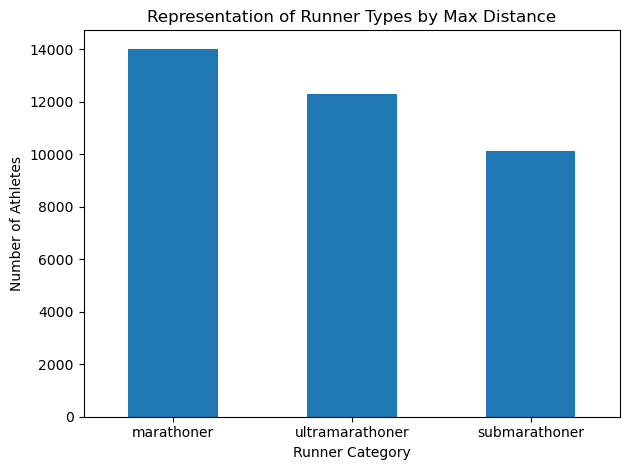

In [13]:
#Find max run per runner

athlete_max = (
    df.groupby("athlete", as_index=False)
      .agg(max_distance=("distance", "max"))
)

#Classify runners as ultramarathoner, marathoner, and submarathoner

def classify_runner(d):
    if d >= 27:
        return "ultramarathoner"
    elif d >= 26.2:
        return "marathoner"
    else:
        return "submarathoner"

athlete_max["category"] = athlete_max["max_distance"].apply(classify_runner)

#Summarize representation of each category of runner based on distance
summary = athlete_max["category"].value_counts()
proportions = athlete_max["category"].value_counts(normalize=True)

print(summary)
print(proportions)

#Bar chart showing count of runner type by distance

import matplotlib.pyplot as plt

# Count categories
counts = athlete_max["category"].value_counts()

plt.figure()
counts.plot(kind="bar")

plt.xlabel("Runner Category")
plt.ylabel("Number of Athletes")
plt.title("Representation of Runner Types by Max Distance")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [16]:
#Find marathoner athlete ID

marathoners = athlete_max[athlete_max["category"] == "marathoner"]["athlete"]
print(marathoners)

#Filter dataset to include only marathoners
df_marathoners = df[df["athlete"].isin(marathoners)].copy()
print(df_marathoners.shape)
print(df_marathoners)

1            1
2            2
4            4
5            5
6            6
         ...  
36344    37531
36354    37541
36358    37545
36373    37560
36379    37566
Name: athlete, Length: 14012, dtype: int64
(10242772, 10)
           datetime  athlete   distance   duration gender age_group  \
1        2019-01-01        1   3.274625  30.200000      M   35 - 54   
2        2019-01-01        2   0.000000   0.000000      M   35 - 54   
4        2019-01-01        4   6.002444  48.650000      M   35 - 54   
5        2019-01-01        5   6.449831  50.133333      F   35 - 54   
6        2019-01-01        6   6.282061  53.183333      M      55 +   
...             ...      ...        ...        ...    ...       ...   
26617104 2020-12-31    37531   0.000000   0.000000      F   18 - 34   
26617114 2020-12-31    37541  10.004073  70.000000      M   18 - 34   
26617118 2020-12-31    37545   0.000000   0.000000      F   18 - 34   
26617133 2020-12-31    37560   7.301109  78.000000      M   35 - 54

gender
M    10399
F     3613
Name: count, dtype: int64
gender
M    0.74215
F    0.25785
Name: proportion, dtype: float64


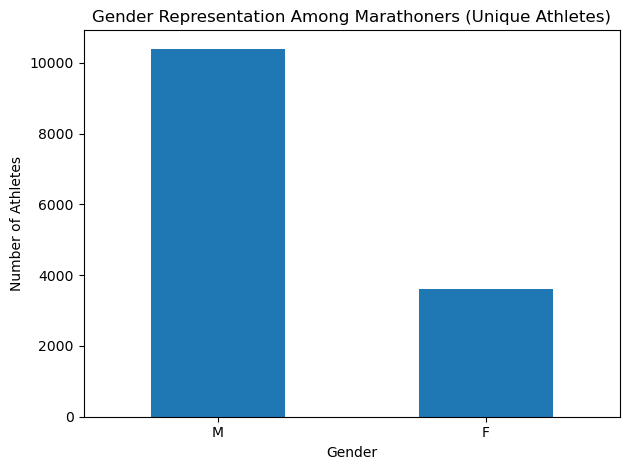

In [18]:
#Identify gender distribution within marathoners

athlete_gender = (
    df_marathoners.groupby("athlete", as_index=False)
    .agg(gender=("gender", "first"))
)

gender_counts = athlete_gender["gender"].value_counts()
gender_props = athlete_gender["gender"].value_counts(normalize=True)

print(gender_counts)
print(gender_props)

#Bar plot
import matplotlib.pyplot as plt

plt.figure()
gender_counts.plot(kind="bar")

plt.xlabel("Gender")
plt.ylabel("Number of Athletes")
plt.title("Gender Representation Among Marathoners (Unique Athletes)")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

gender        F     M
age_group            
18 - 34    1560  3232
35 - 54    1881  6269
55 +        172   898


<Figure size 640x480 with 0 Axes>

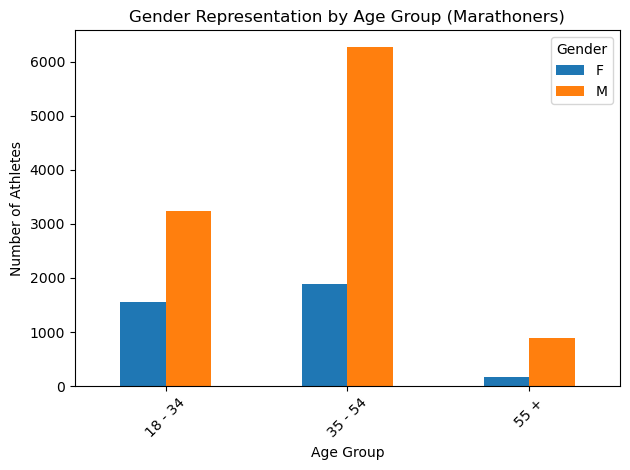

In [19]:
# Identify representation of gender and age group
athlete_demo = (
    df_marathoners.groupby("athlete", as_index=False)
    .agg(
        gender=("gender", "first"),
        age_group=("age_group", "first")
    )
)

#Count combinations 
demo_counts = (
    athlete_demo
    .groupby(["age_group", "gender"])
    .size()
    .unstack(fill_value=0)
)

print(demo_counts)

#Bar plot
import matplotlib.pyplot as plt

plt.figure()
demo_counts.plot(kind="bar")

plt.xlabel("Age Group")
plt.ylabel("Number of Athletes")
plt.title("Gender Representation by Age Group (Marathoners)")

plt.xticks(rotation=45)
plt.legend(title="Gender")
plt.tight_layout()
plt.show()

In [24]:
# athletes classified earlier as marathoners
marathoner_ids = athlete_max.loc[
    athlete_max["category"] == "marathoner", "athlete"
]

# keep only those athletes
df_marathoner_pool = df[df["athlete"].isin(marathoner_ids)].copy()

# now keep only marathon-distance runs within that pool
df_marathon_runs = df_marathoner_pool[
    (df_marathoner_pool["distance"] >= 26.2) & (df_marathoner_pool["distance"] < 27)
].copy()

df_marathon_runs = df_marathon_runs.sort_values(["athlete", "datetime"])

df_marathon_runs["marathon_num"] = (
    df_marathon_runs.groupby("athlete").cumcount() + 1
)

df_marathon_runs["prev_marathon_time"] = (
    df_marathon_runs.groupby("athlete")["duration"].shift(1)
)

print(df_marathon_runs.head())
print(df_marathon_runs["athlete"].nunique())
print((df_marathon_runs["marathon_num"] > 1).sum())
print(df_marathon_runs["prev_marathon_time"].isna().sum())
print(df_marathon_runs.shape[0])
print(df_marathoner_pool["athlete"].nunique())

           datetime  athlete   distance  duration gender age_group  \
4988445  2019-05-18        1  26.346130     270.0      M   35 - 54   
10377421 2019-10-13        1  26.768663     227.0      M   35 - 54   
4260206  2019-04-28        2  26.743808     237.0      M   35 - 54   
6554164  2019-06-30        4  26.315062     217.0      M   35 - 54   
10086128 2019-10-05        4  26.370985     211.0      M   35 - 54   

                 country                    major       date       pace  \
4988445          Germany              BERLIN 2016 2019-05-18  10.248184   
10377421         Germany              BERLIN 2016 2019-10-13   8.480065   
4260206   United Kingdom  LONDON 2018,LONDON 2019 2019-04-28   8.861864   
6554164    United States              BOSTON 2017 2019-06-30   8.246228   
10086128   United States              BOSTON 2017 2019-10-05   8.001218   

          marathon_num  prev_marathon_time  
4988445              1                 NaN  
10377421             2               2

14012
5554
0.3963745361119041 0.6036254638880959


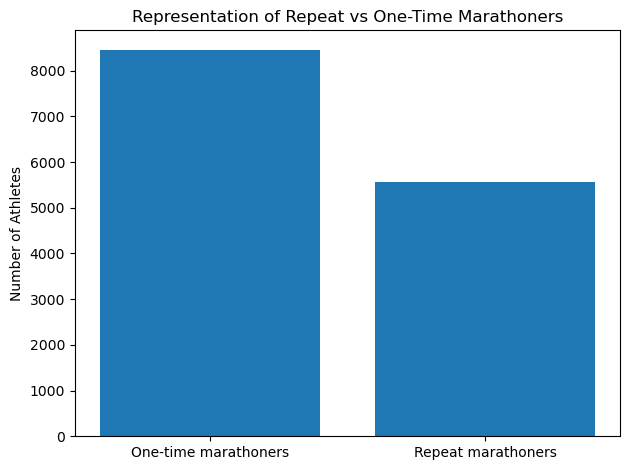

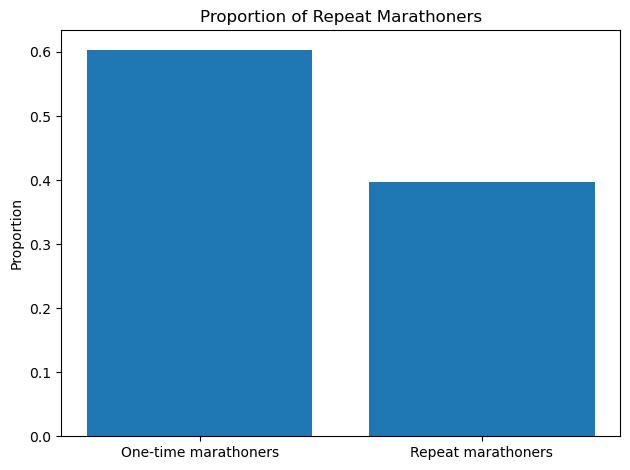

In [25]:
#Find representation of marathoners with availalbe previous time, and those that do not.

# all marathoners (from your earlier classification)
marathoner_ids = set(
    athlete_max.loc[athlete_max["category"] == "marathoner", "athlete"]
)

# repeat marathoners (from your marathon runs dataset)
repeat_ids = set(
    df_marathon_runs[df_marathon_runs["marathon_num"] > 1]["athlete"]
)

num_marathoners = len(marathoner_ids)
num_repeat = len(repeat_ids)

print(num_marathoners)
print(num_repeat)

prop_repeat = num_repeat / num_marathoners
prop_single = 1 - prop_repeat

print(prop_repeat, prop_single)

import matplotlib.pyplot as plt

labels = ["One-time marathoners", "Repeat marathoners"]
values = [num_marathoners - num_repeat, num_repeat]

plt.figure()
plt.bar(labels, values)

plt.ylabel("Number of Athletes")
plt.title("Representation of Repeat vs One-Time Marathoners")

plt.tight_layout()
plt.show()

plt.figure()
plt.bar(labels, [prop_single, prop_repeat])

plt.ylabel("Proportion")
plt.title("Proportion of Repeat Marathoners")

plt.tight_layout()
plt.show()

In [28]:
import pandas as pd

# make sure dates are datetime
df["datetime"] = pd.to_datetime(df["datetime"])

# use the actual column that exists in df_marathon_runs
print(df_marathon_runs.columns)

df_marathon_runs["datetime"] = pd.to_datetime(df_marathon_runs["datetime"])

# build weekly training history from the full dataset
df_active = df[df["distance"] > 0].copy()
df_active["week"] = df_active["datetime"].dt.to_period("W")

weekly = (
    df_active.groupby(["athlete", "week"])["distance"]
    .sum()
    .reset_index()
)

def has_16_weeks(athlete, race_date):
    athlete_weeks = set(weekly.loc[weekly["athlete"] == athlete, "week"])
    race_week = race_date.to_period("W")
    required_weeks = [race_week - i for i in range(1, 17)]
    return all(w in athlete_weeks for w in required_weeks)

df_marathon_runs["has_16wk_training"] = df_marathon_runs.apply(
    lambda row: has_16_weeks(row["athlete"], row["datetime"]),
    axis=1
)



Index(['datetime', 'athlete', 'distance', 'duration', 'gender', 'age_group',
       'country', 'major', 'date', 'pace', 'marathon_num',
       'prev_marathon_time'],
      dtype='object')
          athlete   datetime  has_16wk_training
4988445         1 2019-05-18              False
10377421        1 2019-10-13               True
4260206         2 2019-04-28              False
6554164         4 2019-06-30               True
10086128        4 2019-10-05              False


           datetime  athlete   distance  duration gender age_group  \
4988445  2019-05-18        1  26.346130     270.0      M   35 - 54   
10377421 2019-10-13        1  26.768663     227.0      M   35 - 54   
4260206  2019-04-28        2  26.743808     237.0      M   35 - 54   
6554164  2019-06-30        4  26.315062     217.0      M   35 - 54   
10086128 2019-10-05        4  26.370985     211.0      M   35 - 54   

                 country                    major       date       pace  \
4988445          Germany              BERLIN 2016 2019-05-18  10.248184   
10377421         Germany              BERLIN 2016 2019-10-13   8.480065   
4260206   United Kingdom  LONDON 2018,LONDON 2019 2019-04-28   8.861864   
6554164    United States              BOSTON 2017 2019-06-30   8.246228   
10086128   United States              BOSTON 2017 2019-10-05   8.001218   

          marathon_num  prev_marathon_time  has_16wk_training  
4988445              1                 NaN              False  


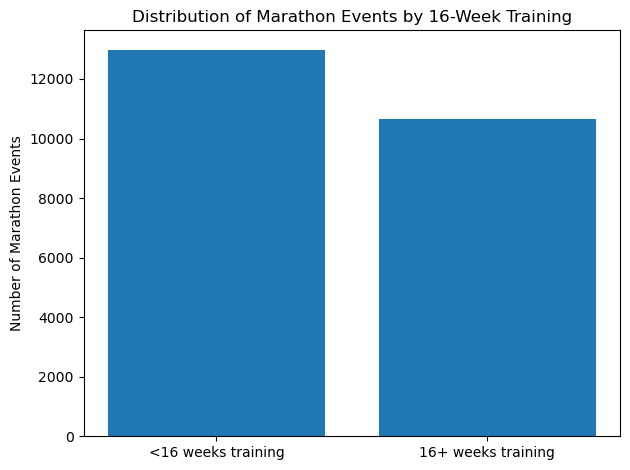

In [31]:
print(df_marathon_runs.head())

counts = df_marathon_runs["has_16wk_training"].value_counts()
props = df_marathon_runs["has_16wk_training"].value_counts(normalize=True)

print(counts)
print(props)

counts = df_marathon_runs["has_16wk_training"].value_counts()
props = df_marathon_runs["has_16wk_training"].value_counts(normalize=True)

print(counts)
print(props)

import matplotlib.pyplot as plt

labels = ["<16 weeks training", "16+ weeks training"]
values = [counts.get(False, 0), counts.get(True, 0)]

plt.figure()
plt.bar(labels, values)

plt.ylabel("Number of Marathon Events")
plt.title("Distribution of Marathon Events by 16-Week Training")

plt.tight_layout()
plt.show()

132.0
360.0
(23156, 13)


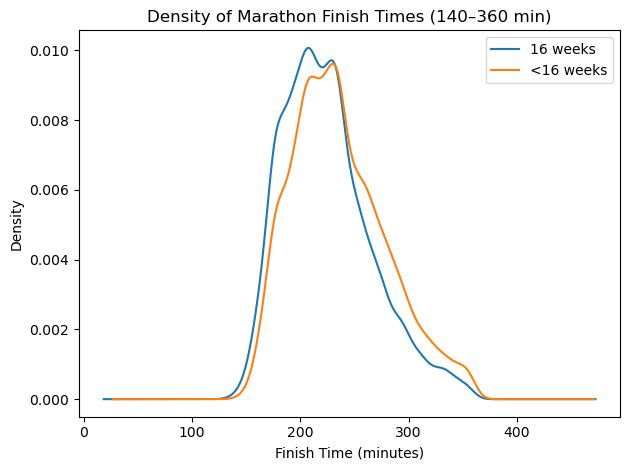

In [36]:
# gender-specific filtering
df_marathon_runs_filtered = df_marathon_runs[
    (df_marathon_runs["duration"] <= 360) & (
        ((df_marathon_runs["gender"] == "M") & (df_marathon_runs["duration"] >= 130)) |
        ((df_marathon_runs["gender"] == "F") & (df_marathon_runs["duration"] >= 140))
    )
].copy()

with_16 = df_marathon_runs_filtered[
    df_marathon_runs_filtered["has_16wk_training"] == True
]

without_16 = df_marathon_runs_filtered[
    df_marathon_runs_filtered["has_16wk_training"] == False
]

print(df_marathon_runs_filtered["duration"].min())
print(df_marathon_runs_filtered["duration"].max())
print(df_marathon_runs_filtered.shape)

plt.figure()

with_16["duration"].plot(kind="kde", label="16 weeks")
without_16["duration"].plot(kind="kde", label="<16 weeks")

plt.xlabel("Finish Time (minutes)")
plt.title("Density of Marathon Finish Times (140–360 min)")

plt.legend()
plt.tight_layout()
plt.show()


In [62]:

# -----------------------------
# 1) Race-level metadata
# -----------------------------
race_meta = df_marathon_runs.copy()
race_meta["datetime"] = pd.to_datetime(race_meta["datetime"])
race_meta["race_date"] = race_meta["datetime"]
race_meta["race_week"] = race_meta["race_date"].dt.to_period("W")

race_meta["race_id"] = (
    race_meta["athlete"].astype(str) + "_" + race_meta["race_date"].astype(str)
)

race_meta = race_meta[[
    "race_id", "athlete", "race_date",
    "gender", "age_group", "country", "major",
    "distance", "duration", "pace",
    "marathon_num", "prev_marathon_time",
    "has_16wk_training"
]].copy()

valid_races = race_meta[race_meta["has_16wk_training"]].copy()
valid_athletes = valid_races["athlete"].unique()


In [68]:
# -----------------------------
# 2) Weekly training table
# -----------------------------
df_active = df[(df["distance"] > 0) & (df["athlete"].isin(valid_athletes))].copy()
df_active["datetime"] = pd.to_datetime(df_active["datetime"])
df_active["week"] = df_active["datetime"].dt.to_period("W")

weekly_base = (
    df_active.groupby(["athlete", "week"], as_index=False)
    .agg(
        total_weekly_mileage=("distance", "sum"),
        total_weekly_duration=("duration", "sum"),
        num_runs=("distance", "count"),
    )
)


In [43]:

# longest run in each athlete-week
longest_idx = df_active.groupby(["athlete", "week"])["distance"].idxmax()
longest = (
    df_active.loc[longest_idx, ["athlete", "week", "distance", "duration", "pace"]]
    .rename(columns={
        "distance": "longest_run_mileage",
        "duration": "longest_run_duration",
        "pace": "longest_run_pace"
    })
)


In [44]:

# fastest run in each athlete-week
fastest_df = df_active[df_active["pace"].notna()].copy()
fastest_idx = fastest_df.groupby(["athlete", "week"])["pace"].idxmin()
fastest = (
    fastest_df.loc[fastest_idx, ["athlete", "week", "distance", "duration", "pace"]]
    .rename(columns={
        "distance": "fastest_run_mileage",
        "duration": "fastest_run_duration",
        "pace": "fastest_run_pace"
    })
)


In [69]:

weekly = (
    weekly_base.merge(longest, on=["athlete", "week"], how="left")
               .merge(fastest, on=["athlete", "week"], how="left")
)

weekly["pace_diff"] = weekly["longest_run_pace"] - weekly["fastest_run_pace"]
weekly["pace_ratio"] = np.where(
    weekly["fastest_run_pace"] > 0,
    weekly["longest_run_pace"] / weekly["fastest_run_pace"],
    np.nan
)

In [70]:
# -----------------------------
# 3) Create race-week mapping
# -----------------------------
race_weeks = valid_races[["race_id", "athlete", "race_date"]].copy()
race_weeks["race_week"] = race_weeks["race_date"].dt.to_period("W")

race_weeks = race_weeks.loc[race_weeks.index.repeat(16)].reset_index(drop=True)
race_weeks["week_num"] = race_weeks.groupby("race_id").cumcount() + 1
race_weeks["train_week"] = race_weeks["race_week"] - race_weeks["week_num"]


In [71]:
# -----------------------------
# 4) Merge ONLY training features
# -----------------------------
race_week_features = race_weeks.merge(
    weekly,
    left_on=["athlete", "train_week"],
    right_on=["athlete", "week"],
    how="left"
)

# drop columns that should not be pivoted
race_week_features = race_week_features.drop(columns=["week", "race_week", "train_week"])


In [73]:
# -----------------------------
# 5) Pivot only the weekly features
# -----------------------------
feature_cols = [
    "total_weekly_mileage",
    "total_weekly_duration",
    "num_runs",
    "longest_run_mileage",
    "longest_run_duration",
    "longest_run_pace",
    "fastest_run_mileage",
    "fastest_run_duration",
    "fastest_run_pace",
    "pace_diff",
    "pace_ratio",
]

wide = race_week_features.pivot(
    index="race_id",
    columns="week_num",
    values=feature_cols
)

wide.columns = [f"{feat}_wk{wk}" for feat, wk in wide.columns]
wide = wide.reset_index()

In [74]:
# -----------------------------
# 6) Merge race-level metadata back once
# -----------------------------
final_df = wide.merge(
    race_meta[[
        "race_id", "athlete", "race_date",
        "gender", "age_group", "country", "major",
        "distance", "duration", "pace",
        "marathon_num", "prev_marathon_time"
    ]],
    on="race_id",
    how="left"
)

print(final_df.shape)
print(final_df.head())

(10661, 188)
            race_id  total_weekly_mileage_wk1  total_weekly_mileage_wk2  \
0  10003_2019-11-10                 11.296525                 41.246607   
1  10010_2020-01-19                 30.167562                 43.359268   
2  10011_2019-06-22                 34.323913                 42.974018   
3  10013_2019-10-13                 23.021796                 33.535393   
4  10013_2019-11-01                 20.511457                  5.144952   

   total_weekly_mileage_wk3  total_weekly_mileage_wk4  \
0                 28.359372                 34.032490   
1                 48.634087                 32.180804   
2                 30.148921                 51.362527   
3                 52.226233                 41.327385   
4                 37.909845                 23.021796   

   total_weekly_mileage_wk5  total_weekly_mileage_wk6  \
0                 17.522041                 35.877962   
1                 41.190684                 41.041555   
2                 31.3

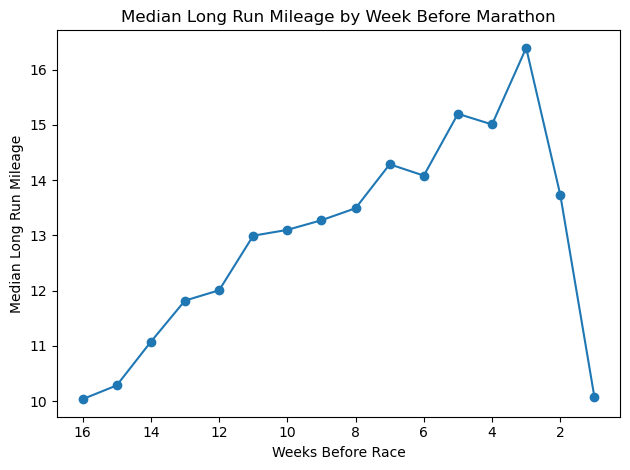

In [75]:
#Representation plot of longest run mileage by week number

median_long_run = (
    race_week_features.groupby("week_num")["longest_run_mileage"]
    .median()
)

plt.figure()
plt.plot(median_long_run.index, median_long_run.values, marker='o')

plt.xlabel("Weeks Before Race")
plt.ylabel("Median Long Run Mileage")
plt.title("Median Long Run Mileage by Week Before Marathon")

plt.gca().invert_xaxis()
plt.tight_layout()
plt.show()

In [83]:
#Take the fasest long run
long_run_pace_cols = [col for col in final_df.columns if "longest_run_pace_wk" in col]

final_df["fastest_long_run_pace"] = final_df[long_run_pace_cols].min(axis=1)

#Mean weekly mileage
mileage_cols = [col for col in final_df.columns if "total_weekly_mileage_wk" in col]

final_df["mean_weekly_mileage"] = final_df[mileage_cols].mean(axis=1)

#Consistency i nmileage
final_df["mileage_std"] = final_df[mileage_cols].std(axis=1)

#Consistency in pace
pace_cols = [col for col in final_df.columns if "longest_run_pace_wk" in col]

final_df["pace_std"] = final_df[pace_cols].std(axis=1)
df_clean = final_df[final_df["pace_std"] <= 15].copy()


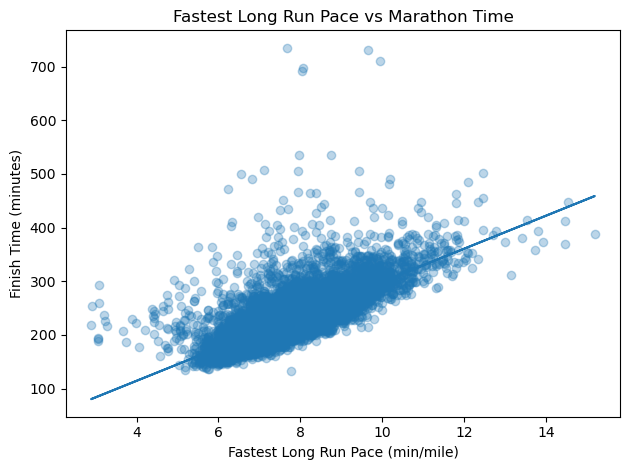

In [77]:
import matplotlib.pyplot as plt
import numpy as np

x = final_df["fastest_long_run_pace"]
y = final_df["duration"]

plt.figure()
plt.scatter(x, y, alpha=0.3)

# regression line
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b)

plt.xlabel("Fastest Long Run Pace (min/mile)")
plt.ylabel("Finish Time (minutes)")
plt.title("Fastest Long Run Pace vs Marathon Time")

plt.tight_layout()
plt.show()

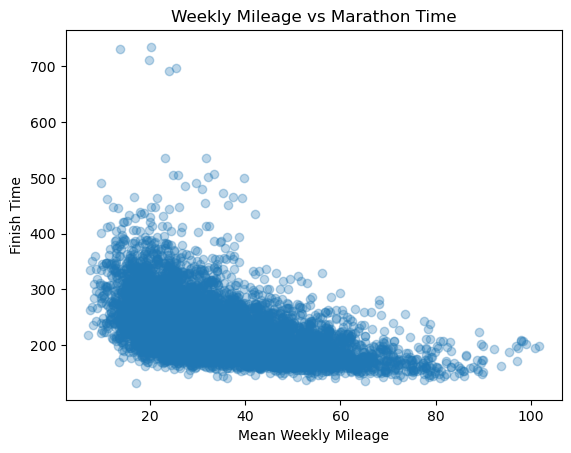

In [79]:
x = final_df["mean_weekly_mileage"]
y = final_df["duration"]

plt.figure()
plt.scatter(x, y, alpha=0.3)

m, b = np.polyfit(x, y, 1)

plt.xlabel("Mean Weekly Mileage")
plt.ylabel("Finish Time")
plt.title("Weekly Mileage vs Marathon Time")

plt.show()

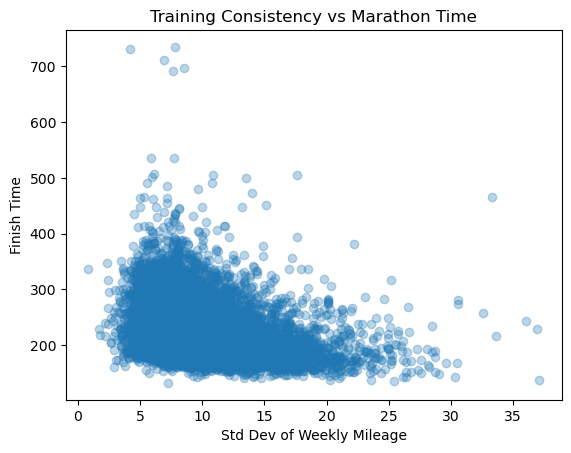

In [81]:
x = final_df["mileage_std"]
y = final_df["duration"]

plt.figure()
plt.scatter(x, y, alpha=0.3)

m, b = np.polyfit(x, y, 1)

plt.xlabel("Std Dev of Weekly Mileage")
plt.ylabel("Finish Time")
plt.title("Training Consistency vs Marathon Time")

plt.show()

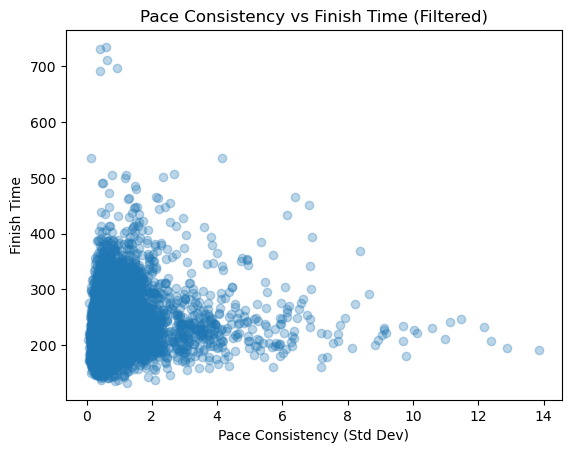

In [85]:
import matplotlib.pyplot as plt
import numpy as np

x = df_clean["pace_std"]
y = df_clean["duration"]

plt.figure()
plt.scatter(x, y, alpha=0.3)

m, b = np.polyfit(x, y, 1)

plt.xlabel("Pace Consistency (Std Dev)")
plt.ylabel("Finish Time")
plt.title("Pace Consistency vs Finish Time (Filtered)")

plt.show()

In [97]:
cluster_df = final_df.copy()

# weekly column lists
mileage_cols = [col for col in cluster_df.columns if "total_weekly_mileage_wk" in col]
pace_cols = [col for col in cluster_df.columns if "longest_run_pace_wk" in col]
long_run_cols = [col for col in cluster_df.columns if "longest_run_mileage_wk" in col]

# summary features
cluster_df["mean_mileage"] = cluster_df[mileage_cols].mean(axis=1)
cluster_df["mean_pace"] = cluster_df[pace_cols].mean(axis=1)
cluster_df["mileage_std"] = cluster_df[mileage_cols].std(axis=1)
cluster_df["pace_std"] = cluster_df[pace_cols].std(axis=1)
cluster_df["max_long_run"] = cluster_df[long_run_cols].max(axis=1)

# filter out implausible values
cluster_df_clean = cluster_df[
    (cluster_df["mean_pace"] < 15) &
    (cluster_df["pace_std"] < 5)
].copy()

print(cluster_df_clean[["mean_mileage", "mean_pace", "mileage_std", "pace_std", "max_long_run"]].head())

   mean_mileage  mean_pace  mileage_std  pace_std  max_long_run
0     27.718933  10.700171    11.183820  0.393389     21.760412
1     35.420361   9.622300     7.769182  0.474820     20.200150
2     36.100374   7.724843     8.733632  0.201935     20.008146
3     36.116413   8.411661     7.738191  0.267421     20.008146
4     34.240649   8.363864    11.415689  0.318501     26.905364


In [98]:
features = [
    "mean_mileage",
    "mean_pace",
    "mileage_std",
    "pace_std",
    "max_long_run"
]

from sklearn.preprocessing import StandardScaler

X = cluster_df[features].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

C:\Users\Shih-An\anaconda3\envs\dtsc680\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\Shih-An\anaconda3\envs\dtsc680\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\Shih-An\anaconda3\envs\dtsc680\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\Shih-An\anaconda3\envs\dtsc680\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_

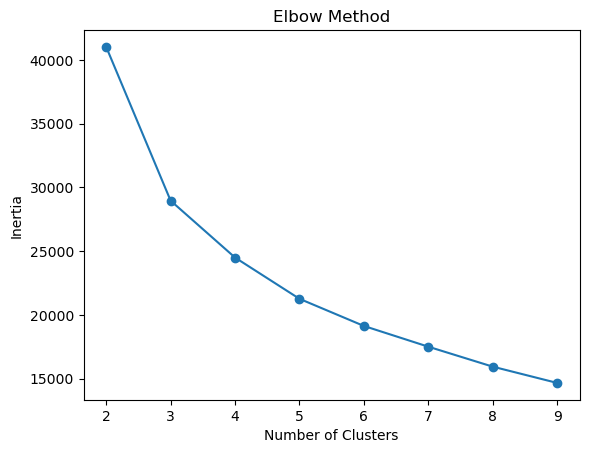

In [99]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(2, 10), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [100]:
kmeans = KMeans(n_clusters=3, random_state=42)
cluster_df["cluster"] = kmeans.fit_predict(X_scaled)

C:\Users\Shih-An\anaconda3\envs\dtsc680\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [101]:
cluster_summary = cluster_df.groupby("cluster")[features].mean()
print(cluster_summary)

         mean_mileage  mean_pace  mileage_std    pace_std  max_long_run
cluster                                                                
0           26.421366   9.218462     8.419289    0.868506     19.602406
1           43.755116   7.998317    12.554435    0.641568     23.456867
2           14.813096  74.232817     9.262752  241.493334     15.108636


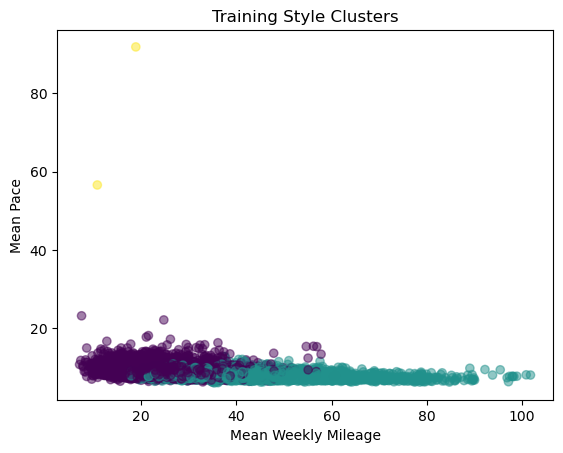

In [102]:
plt.figure()
plt.scatter(cluster_df["mean_mileage"], cluster_df["mean_pace"], 
            c=cluster_df["cluster"], alpha=0.5)

plt.xlabel("Mean Weekly Mileage")
plt.ylabel("Mean Pace")
plt.title("Training Style Clusters")
plt.show()

In [94]:
cluster_df.groupby("cluster")["duration"].mean()

cluster
0    246.022763
1    201.516670
2    293.000000
Name: duration, dtype: float64

In [103]:
import pandas as pd

results = []

for i in range(1, 17):
    col = f"total_weekly_mileage_wk{i}"
    corr = final_df[col].corr(final_df["duration"])
    
    results.append((i, corr))

corr_df = pd.DataFrame(results, columns=["week_num", "correlation"])

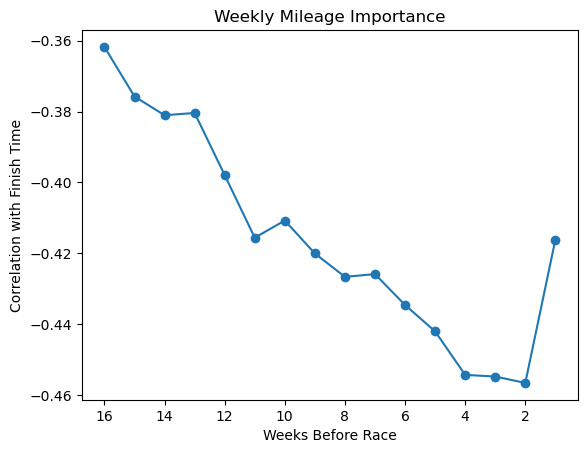

In [104]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(corr_df["week_num"], corr_df["correlation"], marker='o')

plt.xlabel("Weeks Before Race")
plt.ylabel("Correlation with Finish Time")
plt.title("Weekly Mileage Importance")

plt.gca().invert_xaxis()
plt.show()

In [106]:
import pandas as pd

def compute_weekly_correlation(df, feature_prefix, target="duration"):
    results = []
    
    for i in range(1, 17):
        col = f"{feature_prefix}_wk{i}"
        
        if col in df.columns:
            corr = df[col].corr(df[target])
            results.append((i, corr))
    
    return pd.DataFrame(results, columns=["week_num", "correlation"])

In [107]:
mileage_corr = compute_weekly_correlation(final_df, "total_weekly_mileage")

In [108]:
duration_corr = compute_weekly_correlation(final_df, "total_weekly_duration")

In [109]:
long_run_corr = compute_weekly_correlation(final_df, "longest_run_mileage")

In [110]:
pace_corr = compute_weekly_correlation(final_df, "longest_run_pace")

In [111]:
fast_corr = compute_weekly_correlation(final_df, "fastest_run_pace")

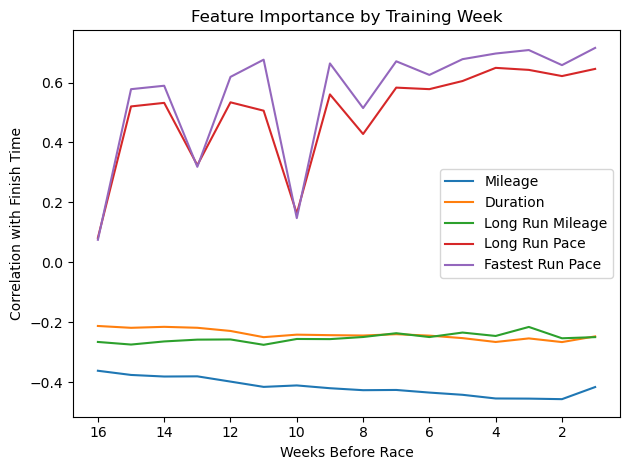

In [112]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(mileage_corr["week_num"], mileage_corr["correlation"], label="Mileage")
plt.plot(duration_corr["week_num"], duration_corr["correlation"], label="Duration")
plt.plot(long_run_corr["week_num"], long_run_corr["correlation"], label="Long Run Mileage")
plt.plot(pace_corr["week_num"], pace_corr["correlation"], label="Long Run Pace")
plt.plot(fast_corr["week_num"], fast_corr["correlation"], label="Fastest Run Pace")

plt.xlabel("Weeks Before Race")
plt.ylabel("Correlation with Finish Time")
plt.title("Feature Importance by Training Week")

plt.gca().invert_xaxis()
plt.legend()
plt.tight_layout()
plt.show()

In [113]:
print("Mileage peak week:", mileage_corr.loc[mileage_corr["correlation"].idxmin()])
print("Long run peak week:", long_run_corr.loc[long_run_corr["correlation"].idxmin()])
print("Pace peak week:", pace_corr.loc[pace_corr["correlation"].idxmin()])

Mileage peak week: week_num       2.00000
correlation   -0.45656
Name: 1, dtype: float64
Long run peak week: week_num       11.000000
correlation    -0.275202
Name: 10, dtype: float64
Pace peak week: week_num       16.000000
correlation     0.081803
Name: 15, dtype: float64


In [114]:
summary = pd.DataFrame({
    "mileage": mileage_corr.set_index("week_num")["correlation"],
    "long_run": long_run_corr.set_index("week_num")["correlation"],
    "pace": pace_corr.set_index("week_num")["correlation"]
})

print(summary)

           mileage  long_run      pace
week_num                              
1        -0.416166 -0.249529  0.645574
2        -0.456560 -0.253399  0.621636
3        -0.454756 -0.215557  0.642283
4        -0.454291 -0.245651  0.649059
5        -0.442006 -0.234294  0.605138
6        -0.434580 -0.249282  0.577986
7        -0.425857 -0.236494  0.583089
8        -0.426626 -0.249132  0.428273
9        -0.420034 -0.256195  0.560492
10       -0.410748 -0.255717  0.162901
11       -0.415584 -0.275202  0.506146
12       -0.397928 -0.257306  0.534016
13       -0.380396 -0.257912  0.324205
14       -0.381030 -0.263925  0.532226
15       -0.375751 -0.274301  0.520361
16       -0.361759 -0.265654  0.081803


In [123]:
import re
import numpy as np
import pandas as pd

# Make a copy so we don't overwrite anything important
model_df = final_df.copy()

# Target
target = "duration"

# Group variable for leakage-safe CV
group_col = "athlete"

# Weekly feature columns
weekly_cols = [
    c for c in model_df.columns 
    if re.search(r"_wk\d+$", c)
    and not (
        c.startswith("total_weekly_duration_") or
        c.startswith("longest_run_duration_") or
        c.startswith("fastest_run_duration_")
    )
]

# Other numeric predictors you may want to keep
numeric_extra = []
for col in ["prev_marathon_time", "marathon_num"]:
    if col in model_df.columns:
        numeric_extra.append(col)

# Categorical predictors
categorical_cols = ["gender", "age_group"]

# Final feature list
feature_cols = weekly_cols + numeric_extra + categorical_cols

# Keep only rows with a target and group
model_df = model_df.dropna(subset=[target, group_col]).copy()

X = model_df[feature_cols].copy()
y = model_df[target].copy()
groups = model_df[group_col].copy()

print("Rows:", model_df.shape[0])
print("Weekly features:", len(weekly_cols))
print("Numeric extras:", numeric_extra)
print("Categoricals:", categorical_cols)

print("Remaining weekly features:")
print([c for c in weekly_cols if "duration" in c])  # should be empty

print("Categorical columns:")
print(categorical_cols)

Rows: 10661
Weekly features: 128
Numeric extras: ['prev_marathon_time', 'marathon_num']
Categoricals: ['gender', 'age_group']
Remaining weekly features:
[]
Categorical columns:
['gender', 'age_group']


In [124]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_cols = weekly_cols + numeric_extra

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ],
    remainder="drop"
)

pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", Ridge())
])

In [125]:
outer_cv = GroupKFold(n_splits=5)
inner_cv = GroupKFold(n_splits=4)

alpha_grid = {
    "model__alpha": np.logspace(-3, 3, 15)
}

outer_results = []
best_alphas = []

for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y, groups=groups), start=1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    g_train = groups.iloc[train_idx]

    search = GridSearchCV(
        estimator=pipe,
        param_grid=alpha_grid,
        cv=inner_cv,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    search.fit(X_train, y_train, groups=g_train)

    best_model = search.best_estimator_
    preds = best_model.predict(X_test)

    rmse = mean_squared_error(y_test, preds, squared=False)
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    outer_results.append({
        "fold": fold,
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "best_alpha": search.best_params_["model__alpha"]
    })
    best_alphas.append(search.best_params_["model__alpha"])

results_df = pd.DataFrame(outer_results)
print(results_df)
print("\nMean performance:")
print(results_df[["rmse", "mae", "r2"]].mean())
print("\nStd performance:")
print(results_df[["rmse", "mae", "r2"]].std())
print("\nBest alphas by fold:")
print(best_alphas)

   fold       rmse        mae        r2   best_alpha
0     1  24.798785  15.901905  0.709773     0.001000
1     2  34.263899  17.235612  0.518937  1000.000000
2     3  27.848742  16.790093  0.643538    51.794747
3     4  24.538544  16.256602  0.680848     0.001000
4     5  33.738522  17.617279  0.518595   138.949549

Mean performance:
rmse    29.037699
mae     16.760298
r2       0.614338
dtype: float64

Std performance:
rmse    4.717926
mae     0.698530
r2      0.090349
dtype: float64

Best alphas by fold:
[0.001, 1000.0, 51.794746792312125, 0.001, 138.9495494373136]


In [126]:
final_alpha = float(np.median(best_alphas))
print("Final alpha:", final_alpha)

final_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", Ridge(alpha=final_alpha))
])

final_pipe.fit(X, y)

Final alpha: 51.794746792312125


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['total_weekly_mileage_wk1',
                                                   'total_weekly_mileage_wk2',
                                                   'total_weekly_mileage_wk3',
                                                   'total_weekly_mileage_wk4',
                                                   'total_weekly_mileage_wk5',
                                                   'total_weekly_mileage_wk6',
                                                   'total_weekly_mileage_wk7',...
                                                   'num_runs_wk5',
                                                   'num_runs_wk6',
                                                   'num_runs_wk7',
                                                   'num_runs_wk8',
                                                   'num_runs_wk9',
                                                   'num_runs_wk10',
                                                   'num_runs_wk11',
                                                   'num_runs_wk12',
                                                   'num_runs_wk13',
                                                   'num_runs_wk14', ...]),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'age_group'])])),
                ('model', Ridge(alpha=51.794746792312125))])

In [127]:
# Get feature names after preprocessing
feature_names_num = numeric_cols

if len(categorical_cols) > 0:
    ohe = final_pipe.named_steps["preprocess"].named_transformers_["cat"].named_steps["onehot"]
    cat_feature_names = ohe.get_feature_names_out(categorical_cols).tolist()
else:
    cat_feature_names = []

all_feature_names = feature_names_num + cat_feature_names

coef = final_pipe.named_steps["model"].coef_

coef_df = pd.DataFrame({
    "feature": all_feature_names,
    "coefficient": coef
}).sort_values("coefficient", key=np.abs, ascending=False)

print(coef_df.head(25))

                     feature  coefficient
122          pace_ratio_wk11     4.515715
106           pace_diff_wk11    -4.056525
82      fastest_run_pace_wk3     3.974830
80      fastest_run_pace_wk1     3.934713
124          pace_ratio_wk13    -3.549313
83      fastest_run_pace_wk4     3.400946
48      longest_run_pace_wk1     3.324182
115           pace_ratio_wk4     3.204016
103            pace_diff_wk8    -2.893683
90     fastest_run_pace_wk11     2.891966
119           pace_ratio_wk8     2.703840
108           pace_diff_wk13     2.560716
125          pace_ratio_wk14    -2.497217
50      longest_run_pace_wk3     2.361237
128       prev_marathon_time     2.319414
99             pace_diff_wk4    -2.295841
49      longest_run_pace_wk2     2.288614
81      fastest_run_pace_wk2     2.232293
64   fastest_run_mileage_wk1    -2.203948
127          pace_ratio_wk16    -2.060334
19              num_runs_wk4    -1.872910
84      fastest_run_pace_wk5     1.833193
129             marathon_num     1

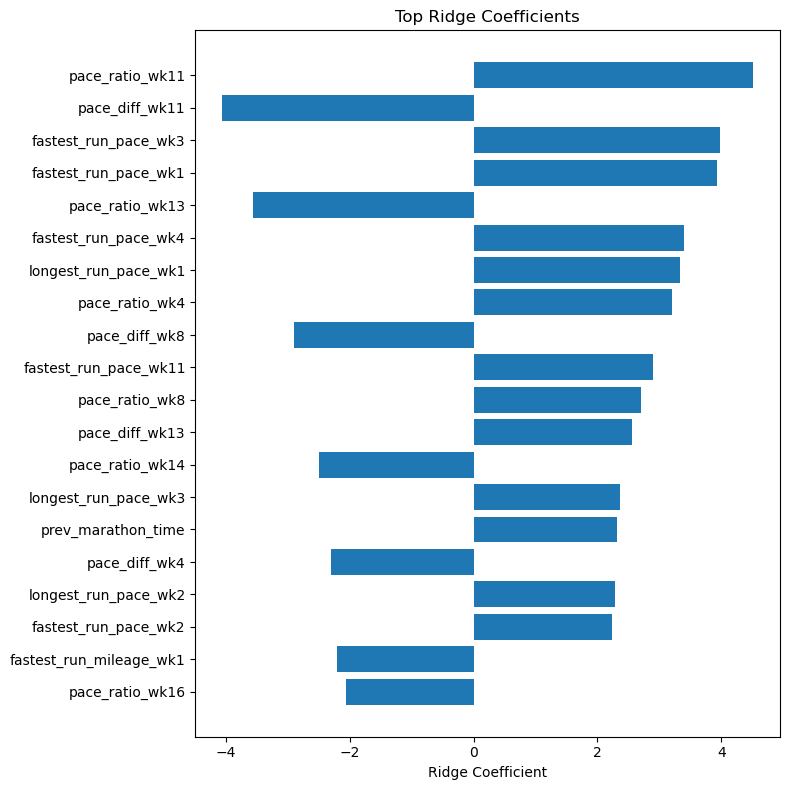

In [128]:
import matplotlib.pyplot as plt

top_coefs = coef_df.head(20).iloc[::-1]

plt.figure(figsize=(8, 8))
plt.barh(top_coefs["feature"], top_coefs["coefficient"])
plt.xlabel("Ridge Coefficient")
plt.title("Top Ridge Coefficients")
plt.tight_layout()
plt.show()

In [133]:
#what type of runners get better predictions?

#compute per-race errors

all_preds = []
all_true = []
all_groups = []
all_indices = []

preds = search.best_estimator_.predict(X_test)

all_preds.extend(preds.tolist())
all_true.extend(y_test.values.tolist())
all_groups.extend(groups.iloc[test_idx].values.tolist())
all_indices.extend(test_idx.tolist())

In [134]:
print(len(all_preds), len(all_true), len(all_groups))

2132 2132 2132


In [137]:
results = pd.DataFrame({
    "pred": all_preds,
    "actual": all_true,
    "athlete": all_groups
})

results["error"] = results["pred"] - results["actual"]
results["abs_error"] = results["error"].abs()

In [138]:
results = results.merge(
    final_df[[
        "athlete",
        "duration",
        "prev_marathon_time"
    ]],
    left_on=["athlete", "actual"],
    right_on=["athlete", "duration"],
    how="left"
)

In [139]:
results["speed_group"] = pd.qcut(results["actual"], 4, labels=["slow", "mid-slow", "mid-fast", "fast"])

results.groupby("speed_group")["abs_error"].mean()

speed_group
slow        12.767311
mid-slow    13.894574
mid-fast    13.997801
fast        29.652953
Name: abs_error, dtype: float64

In [140]:
results["experienced"] = results["prev_marathon_time"].notna()

results.groupby("experienced")["abs_error"].mean()

experienced
False    17.769231
True     17.341910
Name: abs_error, dtype: float64

In [141]:
results = results.merge(
    final_df[["athlete", "pace_std"]],
    on="athlete",
    how="left"
)

results["consistency_group"] = pd.qcut(results["pace_std"], 3)

results.groupby("consistency_group")["abs_error"].mean()

consistency_group
(0.06999999999999999, 0.453]    12.706658
(0.453, 0.706]                  16.281926
(0.706, 324.191]                23.323885
Name: abs_error, dtype: float64

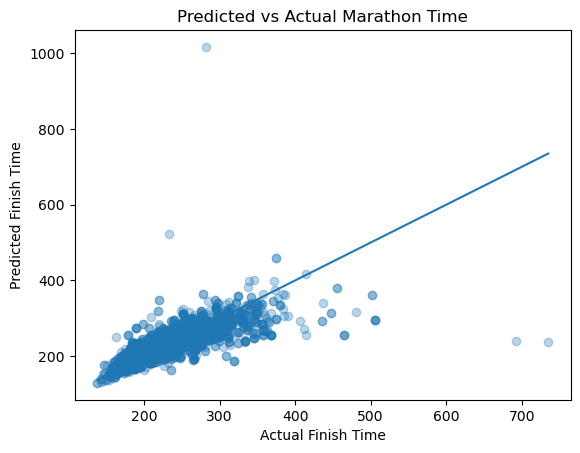

In [143]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(results["actual"], results["pred"], alpha=0.3)

# perfect prediction line
min_val = results["actual"].min()
max_val = results["actual"].max()
plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Actual Finish Time")
plt.ylabel("Predicted Finish Time")
plt.title("Predicted vs Actual Marathon Time")

plt.show()

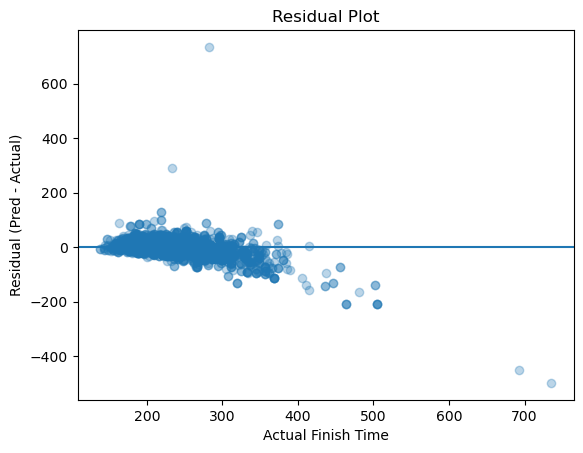

In [144]:
plt.figure()
plt.scatter(results["actual"], results["pred"] - results["actual"], alpha=0.3)

plt.axhline(0)
plt.xlabel("Actual Finish Time")
plt.ylabel("Residual (Pred - Actual)")
plt.title("Residual Plot")

plt.show()

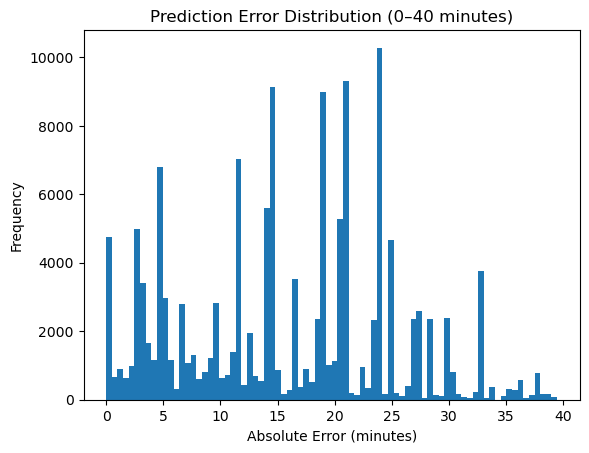

In [152]:
df_plot = results[results["abs_error"] <= 40]

plt.figure()
plt.hist(df_plot["abs_error"], bins=80)

plt.xlabel("Absolute Error (minutes)")
plt.ylabel("Frequency")
plt.title("Prediction Error Distribution (0–40 minutes)")

plt.show()

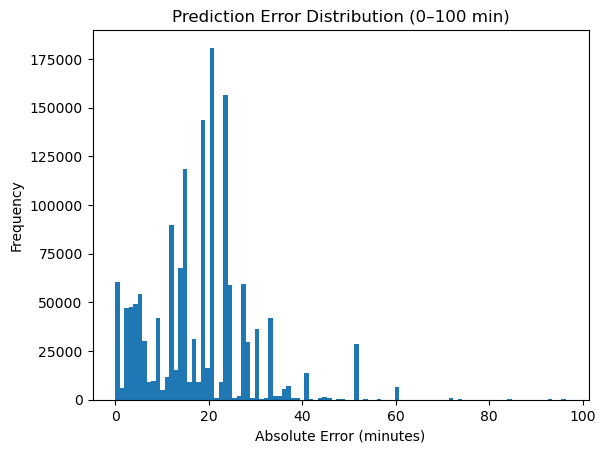

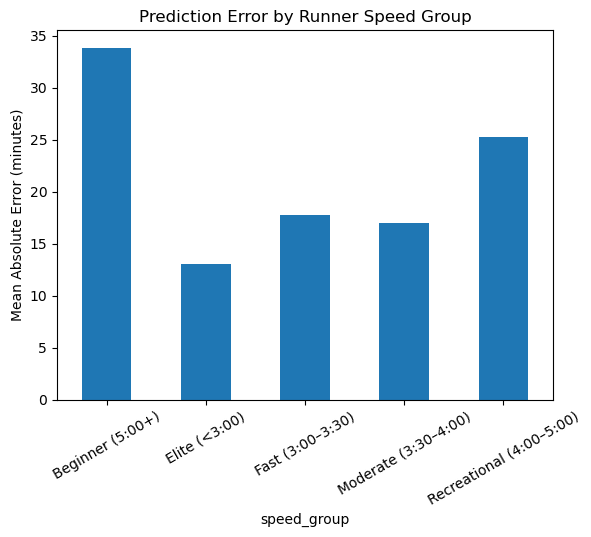

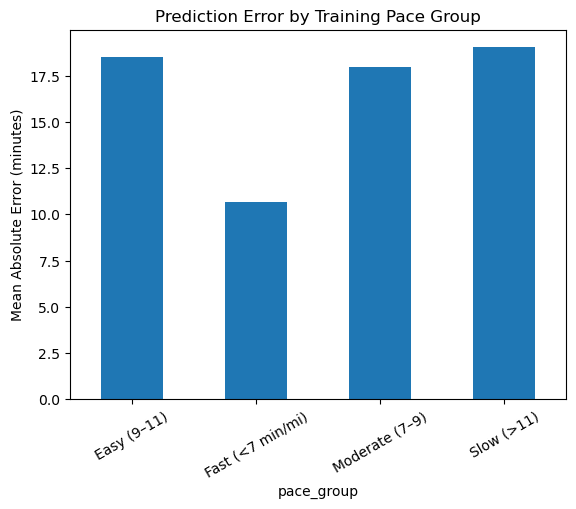

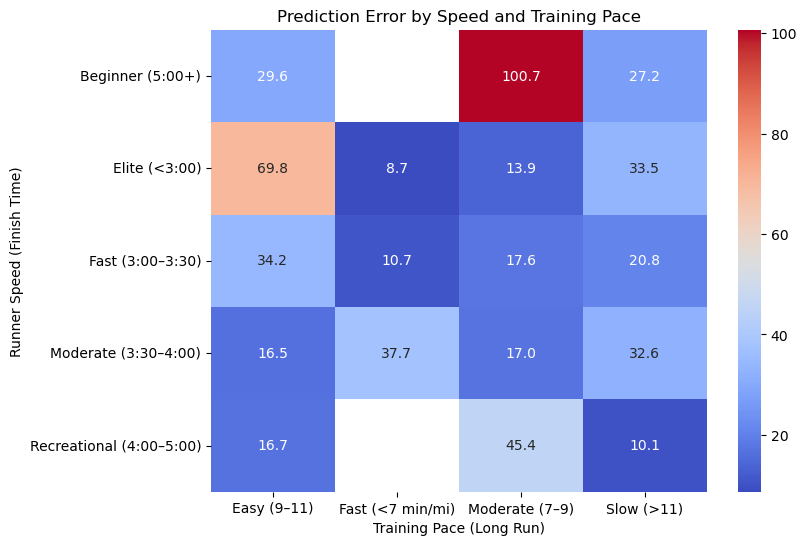

In [153]:
# longest run pace columns
pace_cols = [c for c in final_df.columns if "longest_run_pace_wk" in c]

# average long run pace per race
final_df["long_run_mean_pace"] = final_df[pace_cols].mean(axis=1)

def speed_group(time):
    if time <= 180:
        return "Elite (<3:00)"
    elif time <= 210:
        return "Fast (3:00–3:30)"
    elif time <= 240:
        return "Moderate (3:30–4:00)"
    elif time <= 300:
        return "Recreational (4:00–5:00)"
    else:
        return "Beginner (5:00+)"
    
results["speed_group"] = results["actual"].apply(speed_group)

def pace_group(p):
    if p <= 7:
        return "Fast (<7 min/mi)"
    elif p <= 9:
        return "Moderate (7–9)"
    elif p <= 11:
        return "Easy (9–11)"
    else:
        return "Slow (>11)"
    
# merge pace into results
results = results.merge(
    final_df[["athlete", "long_run_mean_pace"]],
    on="athlete",
    how="left"
)

results["pace_group"] = results["long_run_mean_pace"].apply(pace_group)

import matplotlib.pyplot as plt

df_plot = results[results["abs_error"] <= 100]

plt.figure()
plt.hist(df_plot["abs_error"], bins=100)

plt.xlabel("Absolute Error (minutes)")
plt.ylabel("Frequency")
plt.title("Prediction Error Distribution (0–100 min)")

plt.show()

results.groupby("speed_group")["abs_error"].mean().plot(kind="bar")

plt.ylabel("Mean Absolute Error (minutes)")
plt.title("Prediction Error by Runner Speed Group")

plt.xticks(rotation=30)
plt.show()

results.groupby("pace_group")["abs_error"].mean().plot(kind="bar")

plt.ylabel("Mean Absolute Error (minutes)")
plt.title("Prediction Error by Training Pace Group")

plt.xticks(rotation=30)
plt.show()

import seaborn as sns

pivot = results.pivot_table(
    values="abs_error",
    index="speed_group",
    columns="pace_group",
    aggfunc="mean"
)

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="coolwarm")

plt.title("Prediction Error by Speed and Training Pace")
plt.ylabel("Runner Speed (Finish Time)")
plt.xlabel("Training Pace (Long Run)")

plt.show()

In [172]:
#Random Forest

import numpy as np
import pandas as pd

from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

In [173]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd
import numpy as np

# lighter CV
outer_cv = GroupKFold(n_splits=3)
inner_cv = GroupKFold(n_splits=2)

rf_preprocess = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_cols),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_cols)
    ],
    remainder="drop"
)

rf_pipe = Pipeline(steps=[
    ("preprocess", rf_preprocess),
    ("model", RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ))
])

# much smaller grid
rf_grid = {
    "model__n_estimators": [100],
    "model__max_depth": [10, None],
    "model__min_samples_leaf": [10],
    "model__max_features": ["sqrt"]
}

In [163]:
rf_results = []

for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y, groups=groups), start=1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    g_train = groups.iloc[train_idx]

    search = GridSearchCV(
        rf_pipe,
        rf_grid,
        cv=inner_cv,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    search.fit(X_train, y_train, groups=g_train)
    preds = search.best_estimator_.predict(X_test)

    rf_results.append({
        "fold": fold,
        "rmse": mean_squared_error(y_test, preds, squared=False),
        "mae": mean_absolute_error(y_test, preds),
        "r2": r2_score(y_test, preds),
        "best_params": search.best_params_
    })

rf_results_df = pd.DataFrame(rf_results)
print(rf_results_df)
print(rf_results_df[["rmse", "mae", "r2"]].mean())

   fold       rmse        mae        r2  \
0     1  28.933202  16.495692  0.644653   
1     2  24.856677  16.037554  0.701426   
2     3  25.773088  16.112296  0.694287   

                                                                                                            best_params  
0  {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 10, 'model__n_estimators': 100}  
1  {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 10, 'model__n_estimators': 100}  
2    {'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 10, 'model__n_estimators': 100}  
rmse    26.520989
mae     16.215181
r2       0.680122
dtype: float64


In [181]:
#XGBoost

import numpy as np
import pandas as pd

from xgboost import XGBRegressor
from sklearn.model_selection import GroupKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import randint, uniform


In [182]:
# Preprocess: impute numeric/categorical, one-hot encode categoricals
xgb_preprocess = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_cols),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_cols)
    ],
    remainder="drop"
)

xgb_pipe = Pipeline(steps=[
    ("preprocess", xgb_preprocess),
    ("model", XGBRegressor(
        random_state=42,
        objective="reg:squarederror",
        tree_method="hist",
        n_jobs=-1
    ))
])

# Smaller, faster search space
xgb_dist = {
    "model__n_estimators": randint(100, 200),
    "model__max_depth": randint(3, 5),
    "model__learning_rate": uniform(0.03, 0.07),
    "model__subsample": uniform(0.7, 0.2),
    "model__colsample_bytree": uniform(0.7, 0.2),
}

outer_cv = GroupKFold(n_splits=3)
inner_cv = GroupKFold(n_splits=2)

xgb_results = []

for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y, groups=groups), start=1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    g_train = groups.iloc[train_idx]

    search = RandomizedSearchCV(
        estimator=xgb_pipe,
        param_distributions=xgb_dist,
        n_iter=8,
        cv=inner_cv,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
        random_state=42,
        refit=True
    )

    search.fit(X_train, y_train, groups=g_train)

    preds = search.best_estimator_.predict(X_test)

    xgb_results.append({
        "fold": fold,
        "rmse": mean_squared_error(y_test, preds, squared=False),
        "mae": mean_absolute_error(y_test, preds),
        "r2": r2_score(y_test, preds),
        "best_params": search.best_params_
    })

xgb_results_df = pd.DataFrame(xgb_results)

print(xgb_results_df)
print("\nMean performance:")
print(xgb_results_df[["rmse", "mae", "r2"]].mean())
print("\nStd performance:")
print(xgb_results_df[["rmse", "mae", "r2"]].std())
print("\nBest params by fold:")
for p in xgb_results_df["best_params"]:
    print(p)

   fold       rmse        mae        r2  \
0     1  28.569614  16.192988  0.653528   
1     2  24.702705  15.788166  0.705113   
2     3  25.414241  15.895934  0.702741   

                                                                                                                                                                               best_params  
0  {'model__colsample_bytree': 0.8223705789444758, 'model__learning_rate': 0.03976457024564293, 'model__max_depth': 4, 'model__n_estimators': 159, 'model__subsample': 0.7732723686587383}  
1  {'model__colsample_bytree': 0.7312037280884872, 'model__learning_rate': 0.040919616423534186, 'model__max_depth': 3, 'model__n_estimators': 174, 'model__subsample': 0.873235229154987}  
2  {'model__colsample_bytree': 0.8223705789444758, 'model__learning_rate': 0.03976457024564293, 'model__max_depth': 4, 'model__n_estimators': 159, 'model__subsample': 0.7732723686587383}  

Mean performance:
rmse    26.228853
mae     15.959029
r2       0.68712

In [183]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": ["Ridge", "Random Forest", "XGBoost"],
    "RMSE": [29.04, 26.52, 26.23],
    "MAE": [16.76, 16.22, 15.96],
    "R2": [0.614, 0.680, 0.687]
})

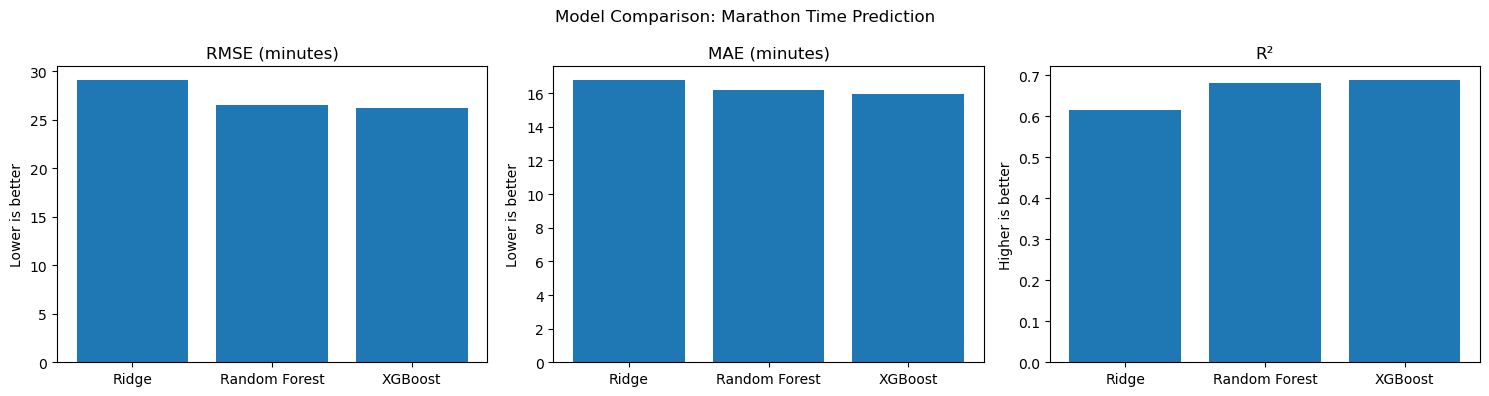

In [184]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# RMSE
axes[0].bar(comparison_df["Model"], comparison_df["RMSE"])
axes[0].set_title("RMSE (minutes)")
axes[0].set_ylabel("Lower is better")

# MAE
axes[1].bar(comparison_df["Model"], comparison_df["MAE"])
axes[1].set_title("MAE (minutes)")
axes[1].set_ylabel("Lower is better")

# R2
axes[2].bar(comparison_df["Model"], comparison_df["R2"])
axes[2].set_title("R²")
axes[2].set_ylabel("Higher is better")

plt.suptitle("Model Comparison: Marathon Time Prediction")
plt.tight_layout()
plt.show()

In [185]:
for ax, metric in zip(axes, ["RMSE", "MAE", "R2"]):
    for i, v in enumerate(comparison_df[metric]):
        ax.text(i, v, f"{v:.2f}", ha='center', va='bottom')

In [186]:
best_rmse = comparison_df["RMSE"].min()

colors = ["gray" if v != best_rmse else "green" for v in comparison_df["RMSE"]]

axes[0].bar(comparison_df["Model"], comparison_df["RMSE"], color=colors)

<BarContainer object of 3 artists>

In [192]:
import os

os.makedirs("model", exist_ok=True)

import joblib
import json

joblib.dump(final_model, "model/marathon_model.pkl")

with open("model/feature_columns.json", "w") as f:
    json.dump(feature_cols, f)

import joblib
import json

joblib.dump(final_model, "model/marathon_model.pkl")

with open("model/feature_columns.json", "w") as f:
    json.dump(feature_cols, f)

In [193]:
import re
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

model_df = final_df.copy()

target = "duration"

# weekly features (already cleaned)
weekly_cols = [c for c in model_df.columns if re.search(r"_wk\d+$", c)]

numeric_extra = ["prev_marathon_time", "marathon_num"]
categorical_cols = ["gender", "age_group"]

feature_cols = weekly_cols + numeric_extra + categorical_cols

X = model_df[feature_cols]
y = model_df[target]

In [194]:
numeric_cols = weekly_cols + numeric_extra

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

In [195]:
final_alpha = 50  # or np.median(best_alphas)

final_model = Pipeline([
    ("preprocess", preprocess),
    ("model", Ridge(alpha=final_alpha))
])

final_model.fit(X, y)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['total_weekly_mileage_wk1',
                                                   'total_weekly_mileage_wk2',
                                                   'total_weekly_mileage_wk3',
                                                   'total_weekly_mileage_wk4',
                                                   'total_weekly_mileage_wk5',
                                                   'total_weekly_mileage_wk6',
                                                   'total_weekly_mileage_wk7',...
                                                   'total_weekly_duration_wk9',
                                                   'total_weekly_duration_wk10',
                                                   'total_weekly_duration_wk11',
                                                   'total_weekly_duration_wk12',
                                                   'total_weekly_duration_wk13',
                                                   'total_weekly_duration_wk14', ...]),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'age_group'])])),
                ('model', Ridge(alpha=50))])

In [196]:
import joblib
import json

joblib.dump(final_model, "model/marathon_model.pkl")

with open("model/feature_columns.json", "w") as f:
    json.dump(feature_cols, f)

In [212]:
import numpy as np
import pandas as pd
import joblib

# Load your trained pipeline
model = joblib.load("trained_model.pkl")

FEATURES = list(model.feature_names_in_)

def _safe_div(numerator, denominator):
    if denominator is None or pd.isna(denominator) or denominator == 0:
        return np.nan
    return numerator / denominator

def build_feature_row(core_inputs: dict) -> pd.DataFrame:
    """
    Build a 1-row DataFrame that matches model.feature_names_in_ exactly.

    Expected keys in core_inputs:
      - gender
      - age_group
      - marathon_num
      - prev_marathon_time
      - for wk1..wk16:
          total_weekly_mileage_wk{i}
          total_weekly_duration_wk{i}
          num_runs_wk{i}
          longest_run_mileage_wk{i}
          longest_run_duration_wk{i}
          fastest_run_mileage_wk{i}
          fastest_run_duration_wk{i}
    """

    row = {}

    # Copy over provided values
    row.update(core_inputs)

    # Compute derived pace features for each week
    for i in range(1, 17):
        l_mile = row.get(f"longest_run_mileage_wk{i}")
        l_dur  = row.get(f"longest_run_duration_wk{i}")
        f_mile = row.get(f"fastest_run_mileage_wk{i}")
        f_dur  = row.get(f"fastest_run_duration_wk{i}")

        longest_pace = _safe_div(l_dur, l_mile)
        fastest_pace = _safe_div(f_dur, f_mile)

        row[f"longest_run_pace_wk{i}"] = longest_pace
        row[f"fastest_run_pace_wk{i}"] = fastest_pace

        if pd.isna(longest_pace) or pd.isna(fastest_pace):
            row[f"pace_diff_wk{i}"] = np.nan
            row[f"pace_ratio_wk{i}"] = np.nan
        else:
            row[f"pace_diff_wk{i}"] = longest_pace - fastest_pace
            row[f"pace_ratio_wk{i}"] = longest_pace / fastest_pace if fastest_pace != 0 else np.nan

    # Build one-row DataFrame
    X = pd.DataFrame([row])

    # Add any missing columns expected by the model
    for col in FEATURES:
        if col not in X.columns:
            X[col] = np.nan

    # Drop any extras and reorder exactly
    X = X[FEATURES]

    return X

def predict_one(core_inputs: dict):
    X = build_feature_row(core_inputs)
    pred = model.predict(X)

    # If classifier with probabilities, show them too
    proba = None
    if hasattr(model, "predict_proba"):
        try:
            proba = model.predict_proba(X)
        except Exception:
            proba = None

    return pred[0], proba, X

# Example input row
example_inputs = {
    "gender": "M",
    "age_group": "55 +",
    "marathon_num": 2,
    "prev_marathon_time": 316.0,

    "total_weekly_mileage_wk1": 11.296525,
    "total_weekly_mileage_wk2": 41.246607,
    "total_weekly_mileage_wk3": 28.359372,
    "total_weekly_mileage_wk4": 34.032490,
    "total_weekly_mileage_wk5": 17.522041,
    "total_weekly_mileage_wk6": 35.877962,
    "total_weekly_mileage_wk7": 52.201378,
    "total_weekly_mileage_wk8": 19.486195,
    "total_weekly_mileage_wk9": 28.179175,
    "total_weekly_mileage_wk10": 12.390138,
    "total_weekly_mileage_wk11": 30.447179,
    "total_weekly_mileage_wk12": 35.542421,
    "total_weekly_mileage_wk13": 30.167562,
    "total_weekly_mileage_wk14": 31.230106,
    "total_weekly_mileage_wk15": 14.223182,
    "total_weekly_mileage_wk16": 21.300598,

    "total_weekly_duration_wk1": 116.116667,
    "total_weekly_duration_wk2": 431.050000,
    "total_weekly_duration_wk3": 302.200000,
    "total_weekly_duration_wk4": 372.016667,
    "total_weekly_duration_wk5": 185.316667,
    "total_weekly_duration_wk6": 362.233333,
    "total_weekly_duration_wk7": 559.683333,
    "total_weekly_duration_wk8": 194.566667,
    "total_weekly_duration_wk9": 303.900000,
    "total_weekly_duration_wk10": 133.016667,
    "total_weekly_duration_wk11": 322.933333,
    "total_weekly_duration_wk12": 377.883333,
    "total_weekly_duration_wk13": 325.000000,
    "total_weekly_duration_wk14": 329.750000,
    "total_weekly_duration_wk15": 153.633333,
    "total_weekly_duration_wk16": 223.000000,

    "num_runs_wk1": 2.0,
    "num_runs_wk2": 4.0,
    "num_runs_wk3": 3.0,
    "num_runs_wk4": 3.0,
    "num_runs_wk5": 3.0,
    "num_runs_wk6": 4.0,
    "num_runs_wk7": 5.0,
    "num_runs_wk8": 3.0,
    "num_runs_wk9": 4.0,
    "num_runs_wk10": 2.0,
    "num_runs_wk11": 4.0,
    "num_runs_wk12": 4.0,
    "num_runs_wk13": 4.0,
    "num_runs_wk14": 4.0,
    "num_runs_wk15": 2.0,
    "num_runs_wk16": 3.0,

    "longest_run_mileage_wk1": 6.847508,
    "longest_run_mileage_wk2": 21.760412,
    "longest_run_mileage_wk3": 15.546702,
    "longest_run_mileage_wk4": 20.511457,
    "longest_run_mileage_wk5": 7.866557,
    "longest_run_mileage_wk6": 18.535497,
    "longest_run_mileage_wk7": 19.274928,
    "longest_run_mileage_wk8": 9.339206,
    "longest_run_mileage_wk9": 13.061218,
    "longest_run_mileage_wk10": 7.083629,
    "longest_run_mileage_wk11": 11.924109,
    "longest_run_mileage_wk12": 14.272892,
    "longest_run_mileage_wk13": 13.055005,
    "longest_run_mileage_wk14": 12.582763,
    "longest_run_mileage_wk15": 9.960577,
    "longest_run_mileage_wk16": 8.823468,

    "longest_run_duration_wk1": 68.0,
    "longest_run_duration_wk2": 230.0,
    "longest_run_duration_wk3": 168.0,
    "longest_run_duration_wk4": 230.0,
    "longest_run_duration_wk5": 85.0,
    "longest_run_duration_wk6": 190.0,
    "longest_run_duration_wk7": 213.0,
    "longest_run_duration_wk8": 93.0,
    "longest_run_duration_wk9": 143.0,
    "longest_run_duration_wk10": 76.0,
    "longest_run_duration_wk11": 135.0,
    "longest_run_duration_wk12": 154.0,
    "longest_run_duration_wk13": 142.0,
    "longest_run_duration_wk14": 133.0,
    "longest_run_duration_wk15": 108.0,
    "longest_run_duration_wk16": 93.0,

    "fastest_run_mileage_wk1": 6.847508,
    "fastest_run_mileage_wk2": 8.736476,
    "fastest_run_mileage_wk3": 8.282875,
    "fastest_run_mileage_wk4": 5.424569,
    "fastest_run_mileage_wk5": 4.988988,
    "fastest_run_mileage_wk6": 5.263012,
    "fastest_run_mileage_wk7": 5.623408,
    "fastest_run_mileage_wk8": 4.411734,
    "fastest_run_mileage_wk9": 4.362024,
    "fastest_run_mileage_wk10": 7.083629,
    "fastest_run_mileage_wk11": 4.511153,
    "fastest_run_mileage_wk12": 8.736476,
    "fastest_run_mileage_wk13": 6.872363,
    "fastest_run_mileage_wk14": 4.604359,
    "fastest_run_mileage_wk15": 4.262605,
    "fastest_run_mileage_wk16": 6.238565,

    "fastest_run_duration_wk1": 68.0,
    "fastest_run_duration_wk2": 89.0,
    "fastest_run_duration_wk3": 84.0,
    "fastest_run_duration_wk4": 55.016667,
    "fastest_run_duration_wk5": 50.333333,
    "fastest_run_duration_wk6": 49.966667,
    "fastest_run_duration_wk7": 55.733333,
    "fastest_run_duration_wk8": 41.566667,
    "fastest_run_duration_wk9": 44.316667,
    "fastest_run_duration_wk10": 76.0,
    "fastest_run_duration_wk11": 44.933333,
    "fastest_run_duration_wk12": 88.0,
    "fastest_run_duration_wk13": 71.0,
    "fastest_run_duration_wk14": 45.75,
    "fastest_run_duration_wk15": 45.633333,
    "fastest_run_duration_wk16": 64.0,
}

pred, proba, X = predict_one(example_inputs)

print("Prediction:", pred)
if proba is not None:
    print("Probabilities:", proba)

print("\nFinal input shape:", X.shape)
print("Missing columns:", [c for c in FEATURES if c not in X.columns])
print(X.head(1).T)

Prediction: 298.5879208321255

Final input shape: (1, 180)
Missing columns: []
                                  0
total_weekly_mileage_wk1  11.296525
total_weekly_mileage_wk2  41.246607
total_weekly_mileage_wk3  28.359372
total_weekly_mileage_wk4   34.03249
total_weekly_mileage_wk5  17.522041
...                             ...
pace_ratio_wk16            1.027421
prev_marathon_time            316.0
marathon_num                      2
gender                            M
age_group                      55 +

[180 rows x 1 columns]


In [216]:
#Testing with row 1, actual is 251.

example_inputs = {
    "gender": "F",
    "age_group": "35 - 54",
    "marathon_num": 2,
    "prev_marathon_time": 244.0,

    "total_weekly_mileage_wk1": 30.167562,
    "total_weekly_mileage_wk2": 43.359268,
    "total_weekly_mileage_wk3": 48.634087,
    "total_weekly_mileage_wk4": 32.180804,
    "total_weekly_mileage_wk5": 41.190684,
    "total_weekly_mileage_wk6": 41.041555,
    "total_weekly_mileage_wk7": 36.294280,
    "total_weekly_mileage_wk8": 35.846272,
    "total_weekly_mileage_wk9": 44.017922,
    "total_weekly_mileage_wk10": 38.301308,
    "total_weekly_mileage_wk11": 36.132724,
    "total_weekly_mileage_wk12": 29.459199,
    "total_weekly_mileage_wk13": 35.641841,
    "total_weekly_mileage_wk14": 27.867868,
    "total_weekly_mileage_wk15": 30.167562,
    "total_weekly_mileage_wk16": 16.422836,

    "total_weekly_duration_wk1": 292.966667,
    "total_weekly_duration_wk2": 414.966667,
    "total_weekly_duration_wk3": 457.650000,
    "total_weekly_duration_wk4": 305.266667,
    "total_weekly_duration_wk5": 380.083333,
    "total_weekly_duration_wk6": 400.533333,
    "total_weekly_duration_wk7": 356.566667,
    "total_weekly_duration_wk8": 358.900000,
    "total_weekly_duration_wk9": 436.000000,
    "total_weekly_duration_wk10": 379.666667,
    "total_weekly_duration_wk11": 347.266667,
    "total_weekly_duration_wk12": 279.150000,
    "total_weekly_duration_wk13": 344.500000,
    "total_weekly_duration_wk14": 273.266667,
    "total_weekly_duration_wk15": 293.450000,
    "total_weekly_duration_wk16": 164.333333,

    "num_runs_wk1": 4.0,
    "num_runs_wk2": 5.0,
    "num_runs_wk3": 4.0,
    "num_runs_wk4": 4.0,
    "num_runs_wk5": 6.0,
    "num_runs_wk6": 5.0,
    "num_runs_wk7": 4.0,
    "num_runs_wk8": 4.0,
    "num_runs_wk9": 5.0,
    "num_runs_wk10": 6.0,
    "num_runs_wk11": 5.0,
    "num_runs_wk12": 5.0,
    "num_runs_wk13": 5.0,
    "num_runs_wk14": 5.0,
    "num_runs_wk15": 6.0,
    "num_runs_wk16": 3.0,

    "longest_run_mileage_wk1": 12.222368,
    "longest_run_mileage_wk2": 18.206170,
    "longest_run_mileage_wk3": 20.200150,
    "longest_run_mileage_wk4": 18.218598,
    "longest_run_mileage_wk5": 13.154424,
    "longest_run_mileage_wk6": 19.007739,
    "longest_run_mileage_wk7": 14.645714,
    "longest_run_mileage_wk8": 20.044807,
    "longest_run_mileage_wk9": 18.001118,
    "longest_run_mileage_wk10": 11.812263,
    "longest_run_mileage_wk11": 12.812670,
    "longest_run_mileage_wk12": 10.749718,
    "longest_run_mileage_wk13": 12.147803,
    "longest_run_mileage_wk14": 10.196698,
    "longest_run_mileage_wk15": 8.195883,
    "longest_run_mileage_wk16": 6.207496,

    "longest_run_duration_wk1": 117.0,
    "longest_run_duration_wk2": 170.0,
    "longest_run_duration_wk3": 197.0,
    "longest_run_duration_wk4": 171.0,
    "longest_run_duration_wk5": 109.0,
    "longest_run_duration_wk6": 185.0,
    "longest_run_duration_wk7": 148.0,
    "longest_run_duration_wk8": 208.0,
    "longest_run_duration_wk9": 180.0,
    "longest_run_duration_wk10": 120.0,
    "longest_run_duration_wk11": 121.0,
    "longest_run_duration_wk12": 101.0,
    "longest_run_duration_wk13": 119.516667,
    "longest_run_duration_wk14": 97.0,
    "longest_run_duration_wk15": 77.0,
    "longest_run_duration_wk16": 59.983333,

    "fastest_run_mileage_wk1": 12.222368,
    "fastest_run_mileage_wk2": 18.206170,
    "fastest_run_mileage_wk3": 8.556279,
    "fastest_run_mileage_wk4": 18.218598,
    "fastest_run_mileage_wk5": 13.154424,
    "fastest_run_mileage_wk6": 6.195069,
    "fastest_run_mileage_wk7": 6.319343,
    "fastest_run_mileage_wk8": 3.299480,
    "fastest_run_mileage_wk9": 3.212488,
    "fastest_run_mileage_wk10": 6.505754,
    "fastest_run_mileage_wk11": 12.812670,
    "fastest_run_mileage_wk12": 4.007843,
    "fastest_run_mileage_wk13": 7.207904,
    "fastest_run_mileage_wk14": 10.196698,
    "fastest_run_mileage_wk15": 8.195883,
    "fastest_run_mileage_wk16": 6.207496,

    "fastest_run_duration_wk1": 117.0,
    "fastest_run_duration_wk2": 170.0,
    "fastest_run_duration_wk3": 78.0,
    "fastest_run_duration_wk4": 171.0,
    "fastest_run_duration_wk5": 109.0,
    "fastest_run_duration_wk6": 58.616667,
    "fastest_run_duration_wk7": 60.0,
    "fastest_run_duration_wk8": 30.7,
    "fastest_run_duration_wk9": 29.8,
    "fastest_run_duration_wk10": 62.0,
    "fastest_run_duration_wk11": 121.0,
    "fastest_run_duration_wk12": 36.15,
    "fastest_run_duration_wk13": 68.0,
    "fastest_run_duration_wk14": 97.0,
    "fastest_run_duration_wk15": 77.0,
    "fastest_run_duration_wk16": 59.983333,
}

pred, proba, X = predict_one(example_inputs)

print("Prediction:", pred)
if proba is not None:
    print("Probabilities:", proba)

print("\nFinal input shape:", X.shape)
print("Missing columns:", [c for c in FEATURES if c not in X.columns])
print(X.head(1).T)

Prediction: 249.88491482285775

Final input shape: (1, 180)
Missing columns: []
                                  0
total_weekly_mileage_wk1  30.167562
total_weekly_mileage_wk2  43.359268
total_weekly_mileage_wk3  48.634087
total_weekly_mileage_wk4  32.180804
total_weekly_mileage_wk5  41.190684
...                             ...
pace_ratio_wk16                 1.0
prev_marathon_time            244.0
marathon_num                      2
gender                            F
age_group                   35 - 54

[180 rows x 1 columns]


In [217]:
#testing with row 2: actualy 208

example_inputs = {
    "gender": "F",
    "age_group": "18 - 34",
    "marathon_num": 1,
    "prev_marathon_time": np.nan,

    "total_weekly_mileage_wk1": 34.323913,
    "total_weekly_mileage_wk2": 42.974018,
    "total_weekly_mileage_wk3": 30.148921,
    "total_weekly_mileage_wk4": 51.362527,
    "total_weekly_mileage_wk5": 31.366808,
    "total_weekly_mileage_wk6": 42.501776,
    "total_weekly_mileage_wk7": 27.483239,
    "total_weekly_mileage_wk8": 19.045021,
    "total_weekly_mileage_wk9": 38.679723,
    "total_weekly_mileage_wk10": 45.614224,
    "total_weekly_mileage_wk11": 29.720175,
    "total_weekly_mileage_wk12": 29.614542,
    "total_weekly_mileage_wk13": 38.282667,
    "total_weekly_mileage_wk14": 46.261071,
    "total_weekly_mileage_wk15": 27.800139,
    "total_weekly_mileage_wk16": 42.427212,

    "total_weekly_duration_wk1": 274.083333,
    "total_weekly_duration_wk2": 340.500000,
    "total_weekly_duration_wk3": 238.266667,
    "total_weekly_duration_wk4": 412.883333,
    "total_weekly_duration_wk5": 244.816667,
    "total_weekly_duration_wk6": 337.466667,
    "total_weekly_duration_wk7": 209.366667,
    "total_weekly_duration_wk8": 150.050000,
    "total_weekly_duration_wk9": 305.483333,
    "total_weekly_duration_wk10": 357.533333,
    "total_weekly_duration_wk11": 232.483333,
    "total_weekly_duration_wk12": 223.833333,
    "total_weekly_duration_wk13": 302.350000,
    "total_weekly_duration_wk14": 359.550000,
    "total_weekly_duration_wk15": 221.883333,
    "total_weekly_duration_wk16": 330.866667,

    "num_runs_wk1": 5.0,
    "num_runs_wk2": 5.0,
    "num_runs_wk3": 4.0,
    "num_runs_wk4": 6.0,
    "num_runs_wk5": 5.0,
    "num_runs_wk6": 5.0,
    "num_runs_wk7": 4.0,
    "num_runs_wk8": 2.0,
    "num_runs_wk9": 6.0,
    "num_runs_wk10": 6.0,
    "num_runs_wk11": 5.0,
    "num_runs_wk12": 4.0,
    "num_runs_wk13": 6.0,
    "num_runs_wk14": 5.0,
    "num_runs_wk15": 4.0,
    "num_runs_wk16": 5.0,

    "longest_run_mileage_wk1": 12.004888,
    "longest_run_mileage_wk2": 20.008146,
    "longest_run_mileage_wk3": 10.109706,
    "longest_run_mileage_wk4": 20.008146,
    "longest_run_mileage_wk5": 9.339206,
    "longest_run_mileage_wk6": 16.435263,
    "longest_run_mileage_wk7": 13.191706,
    "longest_run_mileage_wk8": 17.000711,
    "longest_run_mileage_wk9": 10.133940,
    "longest_run_mileage_wk10": 16.018944,
    "longest_run_mileage_wk11": 12.029743,
    "longest_run_mileage_wk12": 13.110928,
    "longest_run_mileage_wk13": 10.041355,
    "longest_run_mileage_wk14": 16.012731,
    "longest_run_mileage_wk15": 9.494549,
    "longest_run_mileage_wk16": 14.030557,

    "longest_run_duration_wk1": 97.0,
    "longest_run_duration_wk2": 157.0,
    "longest_run_duration_wk3": 78.0,
    "longest_run_duration_wk4": 156.0,
    "longest_run_duration_wk5": 71.0,
    "longest_run_duration_wk6": 130.0,
    "longest_run_duration_wk7": 97.0,
    "longest_run_duration_wk8": 133.0,
    "longest_run_duration_wk9": 78.0,
    "longest_run_duration_wk10": 123.0,
    "longest_run_duration_wk11": 93.0,
    "longest_run_duration_wk12": 95.0,
    "longest_run_duration_wk13": 77.816667,
    "longest_run_duration_wk14": 124.0,
    "longest_run_duration_wk15": 73.233333,
    "longest_run_duration_wk16": 111.0,

    "fastest_run_mileage_wk1": 8.270448,
    "fastest_run_mileage_wk2": 20.008146,
    "fastest_run_mileage_wk3": 10.109706,
    "fastest_run_mileage_wk4": 20.008146,
    "fastest_run_mileage_wk5": 5.051746,
    "fastest_run_mileage_wk6": 7.015279,
    "fastest_run_mileage_wk7": 13.191706,
    "fastest_run_mileage_wk8": 17.000711,
    "fastest_run_mileage_wk9": 10.133940,
    "fastest_run_mileage_wk10": 16.018944,
    "fastest_run_mileage_wk11": 8.009472,
    "fastest_run_mileage_wk12": 13.110928,
    "fastest_run_mileage_wk13": 8.183456,
    "fastest_run_mileage_wk14": 9.146581,
    "fastest_run_mileage_wk15": 9.494549,
    "fastest_run_mileage_wk16": 9.065803,

    "fastest_run_duration_wk1": 63.0,
    "fastest_run_duration_wk2": 157.0,
    "fastest_run_duration_wk3": 78.0,
    "fastest_run_duration_wk4": 156.0,
    "fastest_run_duration_wk5": 37.733333,
    "fastest_run_duration_wk6": 53.650000,
    "fastest_run_duration_wk7": 97.0,
    "fastest_run_duration_wk8": 133.0,
    "fastest_run_duration_wk9": 78.0,
    "fastest_run_duration_wk10": 123.0,
    "fastest_run_duration_wk11": 60.0,
    "fastest_run_duration_wk12": 95.0,
    "fastest_run_duration_wk13": 62.0,
    "fastest_run_duration_wk14": 69.0,
    "fastest_run_duration_wk15": 73.233333,
    "fastest_run_duration_wk16": 67.0,
}

pred, proba, X = predict_one(example_inputs)

print("Prediction:", pred)
if proba is not None:
    print("Probabilities:", proba)

print("\nFinal input shape:", X.shape)
print("Missing columns:", [c for c in FEATURES if c not in X.columns])
print(X.head(1).T)

Prediction: 197.72889456388316

Final input shape: (1, 180)
Missing columns: []
                                  0
total_weekly_mileage_wk1  34.323913
total_weekly_mileage_wk2  42.974018
total_weekly_mileage_wk3  30.148921
total_weekly_mileage_wk4  51.362527
total_weekly_mileage_wk5  31.366808
...                             ...
pace_ratio_wk16            1.070482
prev_marathon_time              NaN
marathon_num                      1
gender                            F
age_group                   18 - 34

[180 rows x 1 columns]


In [2]:
import sys
!{sys.executable} -m pip install flask
from flask import Flask, render_template, request
import joblib
import json
import os
import pandas as pd
import numpy as np

app = Flask(__name__)

MODEL_PATH = os.path.join("model", "marathon_model.pkl")
FEATURES_PATH = os.path.join("model", "feature_columns.json")

model = joblib.load(MODEL_PATH)

with open(FEATURES_PATH, "r") as f:
    feature_columns = json.load(f)


@app.route("/")
def home():
    return render_template("home.html")


@app.route("/resume")
def resume():
    return render_template("resume.html")


@app.route("/projects")
def projects():
    return render_template("projects.html")


@app.route("/projects/marathon", methods=["GET", "POST"])
def marathon_project():
    prediction = None
    error = None

    if request.method == "POST":
        try:
            row = {}
            for col in feature_columns:
                val = request.form.get(col, "").strip()

                # blank fields become NaN
                if val == "":
                    row[col] = np.nan
                else:
                    # try numeric first; otherwise keep as text
                    try:
                        row[col] = float(val)
                    except ValueError:
                        row[col] = val

            input_df = pd.DataFrame([row])
            pred = model.predict(input_df)[0]
            prediction = round(float(pred), 2)

        except Exception as e:
            error = str(e)

    return render_template(
        "marathon_project.html",
        feature_columns=feature_columns,
        prediction=prediction,
        error=error
    )


if __name__ == "__main__":
    app.run(debug=True)

 * Serving Flask app '__main__'
 * Debug mode: on


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
 * Restarting with stat


SystemExit: 1